(hsgp-boundary-conditions)=
# Boundary Conditions in the Hilbert Space GP Approximation

:::{post} September, 2026
:tags: gaussian processes, hsgp, forecasting
:category: intermediate
:author: Juan Orduz
:::

The Hilbert space Gaussian process approximation (HSGP, {cite:t}`solin2020hilbert`,
{cite:t}`riutort2023practical`) represents a stationary GP on a box $[-L, L]$ using the
eigenfunctions of the Laplacian. Those eigenfunctions depend on what we ask the GP to do at the
ends of the box. This notebook explains the four boundary conditions available in
{class}`pymc.gp.HSGP`, shows where the choice makes no difference at all, where it is the only
way to express what you know about the function, and where it helps with caveats.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

import pymc as pm

from pymc.gp.hsgp_approx import calc_eigenvalues, calc_eigenvectors

In [2]:
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [11, 4]
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = "retina"

seed = 42
rng = np.random.default_rng(seed)

## What a boundary condition is

HSGP approximates the GP prior by $f(x) \approx \sum_{j} \sqrt{S(\omega_j)}\, \beta_j\, \phi_j(x)$
with $\beta_j \sim \mathcal{N}(0, 1)$, where $S$ is the spectral density of the covariance
function and $\phi_j$ are eigenfunctions of the Laplacian on $[-L, L]$. All four options share
the eigenvalues $\lambda_j = (\pi j / 2L)^2$, $\omega_j = \sqrt{\lambda_j}$, and differ only in
the index set $j$ and in the trigonometric function:

| `boundary` | at $-L$ | at $+L$ | $\phi_j(x)$ | $j$ |
|---|---|---|---|---|
| `"dirichlet"` (default) | $f = 0$ | $f = 0$ | $\sin(\omega_j (x + L)) / \sqrt{L}$ | $1, 2, \dots, m$ |
| `"neumann"` | $f' = 0$ | $f' = 0$ | $\cos(\omega_j (x + L)) / \sqrt{L}$ | $0, 1, \dots, m-1$ |
| `"dirichlet-neumann"` | $f = 0$ | $f' = 0$ | $\sin(\omega_j (x + L)) / \sqrt{L}$ | $\tfrac12, \tfrac32, \dots, m - \tfrac12$ |
| `"neumann-dirichlet"` | $f' = 0$ | $f = 0$ | $\cos(\omega_j (x + L)) / \sqrt{L}$ | $\tfrac12, \tfrac32, \dots, m - \tfrac12$ |

The name reads left to right as (condition at the lower end, condition at the upper end).
Dirichlet pins the *value* of the function to zero at the end, Neumann pins its *slope*. The two
mixed conditions are mirror images of each other, so below we only show `"neumann-dirichlet"`.
The constant Neumann mode ($j = 0$, normalised by $1/\sqrt{2L}$) is part of the basis: it
carries the prior variance $S(0) / 2L$ that the other modes do not.

The box itself is centred on the midpoint of the training inputs, with half-width $L$ (given
directly, or as $c$ times the half-range of the data). Keep that in mind: a boundary condition
acts at the ends of the *box*, which are only the ends of your *domain* if you place them there.

Text(0.5, 1.02, 'First four basis functions on $[-L, L]$, $L = 1$')

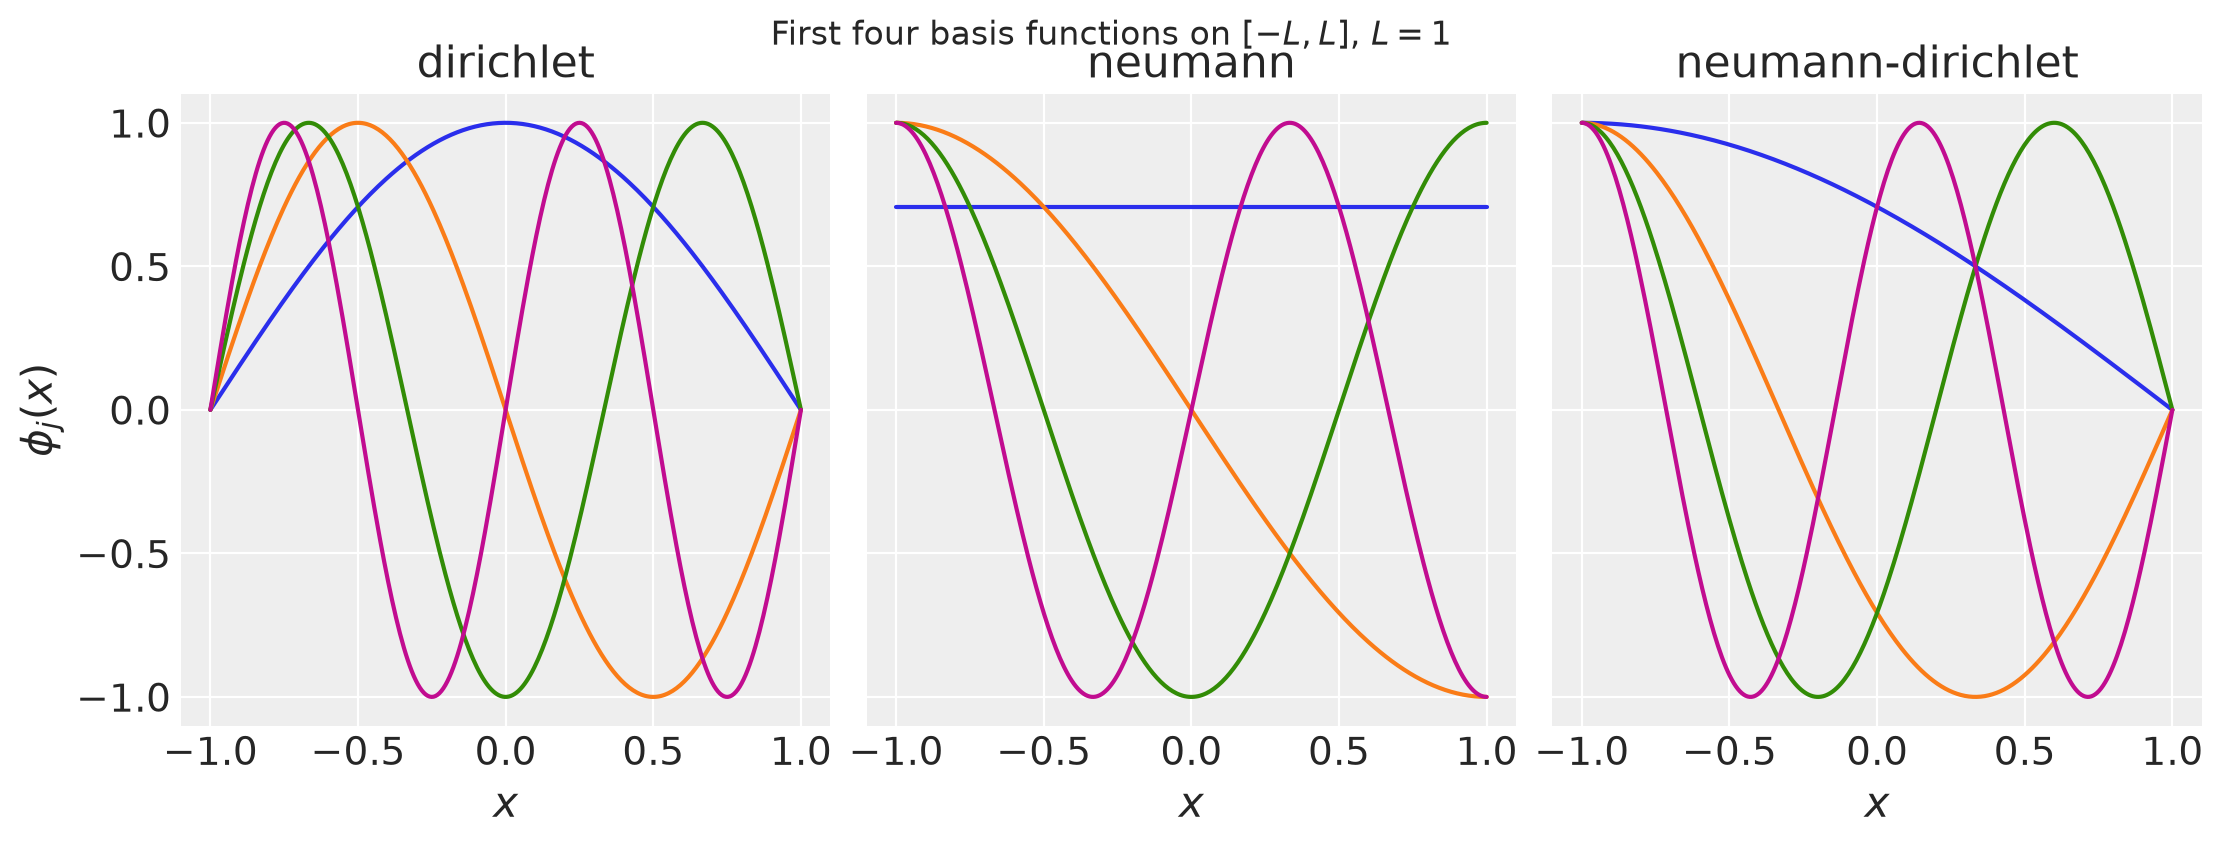

In [3]:
BOUNDARIES = ["dirichlet", "neumann", "neumann-dirichlet"]

L_demo = np.array([1.0])
x_demo = np.linspace(-1.0, 1.0, 300)[:, None]

fig, axes = plt.subplots(1, 3, sharey=True)
for ax, boundary in zip(axes, BOUNDARIES):
    eigvals = calc_eigenvalues(L_demo, [4], boundary=boundary)
    phi = calc_eigenvectors(x_demo, L_demo, eigvals, [4], boundary=boundary).eval()
    ax.plot(x_demo, phi)
    ax.set(title=boundary, xlabel="$x$")
axes[0].set(ylabel=r"$\phi_j(x)$")
fig.suptitle("First four basis functions on $[-L, L]$, $L = 1$", y=1.02)

## What it does to the prior

The prior standard deviation of the approximate GP can be computed in closed form from the
basis and the spectral density. The exact stationary GP has constant standard deviation
$\sigma = 1$.

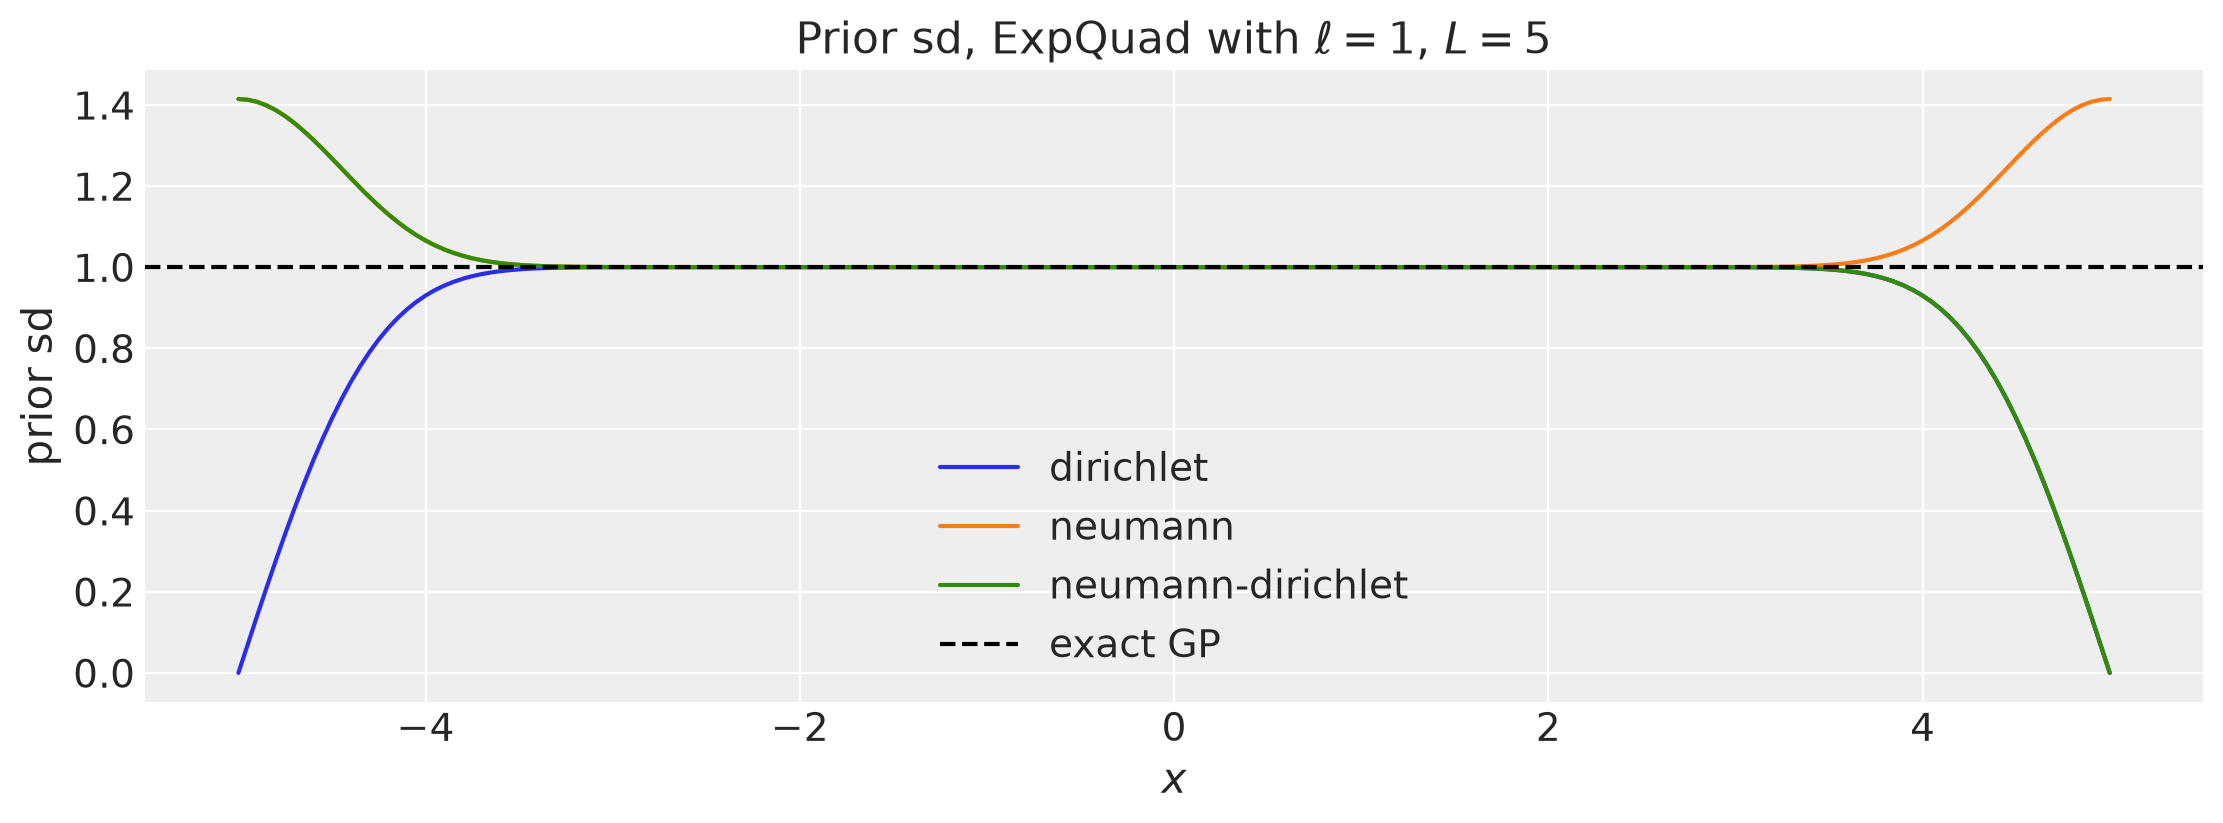

In [4]:
def prior_sd(boundary, X, L, m, ls):
    with pm.Model():
        gp = pm.gp.HSGP(m=[m], L=[L], boundary=boundary, cov_func=pm.gp.cov.ExpQuad(1, ls=ls))
        phi, sqrt_psd = gp.prior_linearized(X)
    return np.sqrt(((phi**2) * sqrt_psd**2).sum(axis=1).eval())


X_prior = np.linspace(-5.0, 5.0, 201)[:, None]
fig, ax = plt.subplots()
for boundary in BOUNDARIES:
    ax.plot(X_prior, prior_sd(boundary, X_prior, L=5.0, m=200, ls=1.0), label=boundary)
ax.axhline(1.0, color="k", ls="--", label="exact GP")
ax.set(xlabel="$x$", ylabel="prior sd", title=r"Prior sd, ExpQuad with $\ell = 1$, $L = 5$")
ax.legend()

Three things to read off this plot:

1. In the interior all conditions agree with the exact GP. The boundary condition only acts
   within roughly $1.5 \ell$ of an end.
2. At a Dirichlet end the prior variance goes to $0$; at a Neumann end it goes to $2\sigma^2$.
   Neither is the exact GP. In the limit $m \to \infty$ the approximate covariance is the
   stationary kernel plus its *reflection* about the ends ("method of images"): with a minus
   sign for Dirichlet, a plus sign for Neumann. The size of the deviation from the exact GP is
   the same in all cases.
3. Consequently the usual guidance for $m$ and $c$ (`pm.gp.hsgp_approx.approx_hsgp_hyperparams`)
   applies unchanged to every boundary condition. A boundary condition is a **modeling
   assumption about what happens at the edge**, not a better approximation of the GP.

## Shared helpers

Two kinds of fits are used below.

- For the **figures**, one NUTS fit per model with weakly informative priors on the
  hyperparameters, compared against the exact GP (`pm.gp.Marginal`).
- For the **tables**, a replicated study: 100 GP draws, and for each draw and each model the
  hyperparameters $(\ell, \eta, \sigma_\text{noise})$ are learned by type-II maximum likelihood
  on a grid, followed by the closed-form Gaussian posterior. This is what NUTS estimates, without
  the sampling noise, and it is cheap enough to replicate. A table from a single realisation is
  not evidence: with a lengthscale of $0.4$ the twenty forecast points are essentially one draw.

A practical note on $m$. With a free lengthscale, the spectral density of the highest
frequencies in the basis underflows to exactly zero once $\ell$ is a few times larger than
$L / m$, and the gradient of $\sqrt{S}$ is then infinite: NUTS diverges. Keep $m$ close to what
`approx_hsgp_hyperparams` recommends for your lengthscale range rather than "large to be safe".
Here $m = 15$ at $c = 1.5$ (and $m = 6$ at $c = 1$) is plenty for $\ell \in [0.2, 0.8]$; the
same $m$ is used for the figures and the tables.

In [5]:
def hyperpriors():
    ell = pm.InverseGamma("ell", mu=0.4, sigma=0.2)
    eta = pm.HalfNormal("eta", sigma=1.5)
    sigma = pm.HalfNormal("sigma", sigma=0.5)
    return eta**2 * pm.gp.cov.ExpQuad(1, ls=ell), sigma


NUTS = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "target_accept": 0.99,
    "random_seed": seed,
    "progressbar": False,
}
PPC = {"random_seed": seed, "progressbar": False}


def stack(ds, name):
    return ds[name].stack(sample=("chain", "draw")).values


def fit_hsgp(boundary, X, y, X_new, m=15, c=1.5):
    with pm.Model():
        cov_func, sigma = hyperpriors()
        gp = pm.gp.HSGP(m=[m], c=c, boundary=boundary, cov_func=cov_func)
        f = gp.prior("f", X=X)
        pm.Normal("y", mu=f, sigma=sigma, observed=y)
        idata = pm.sample(**NUTS)
        gp.conditional("f_new", Xnew=X_new)
        ppc = pm.sample_posterior_predictive(idata, var_names=["f_new"], **PPC)
    return stack(ppc.posterior_predictive, "f_new")


def fit_exact(X, y, X_new):
    with pm.Model():
        cov_func, sigma = hyperpriors()
        gp = pm.gp.Marginal(cov_func=cov_func)
        gp.marginal_likelihood("y", X=X, y=y, sigma=sigma)
        idata = pm.sample(**NUTS)
        gp.conditional("f_new", Xnew=X_new)
        ppc = pm.sample_posterior_predictive(idata, var_names=["f_new"], **PPC)
    return stack(ppc.posterior_predictive, "f_new")


def plot_results(results, x, y, x_all, f_all, x_new, title, vlines=()):
    fig, ax = plt.subplots()
    ax.plot(x, y, "k.", ms=4, label="data")
    ax.plot(x_all, f_all, "k-", lw=1, label="truth")
    for name, s in results.items():
        mu, lo, hi = s.mean(1), np.quantile(s, 0.05, axis=1), np.quantile(s, 0.95, axis=1)
        ax.plot(x_new, mu, label=name)
        ax.fill_between(x_new, lo, hi, alpha=0.15)
    for v, lab in vlines:
        ax.axvline(v, color="gray", ls=":", label=lab)
    ax.set(title=title, xlabel="$x$")
    ax.legend(loc="upper left", fontsize=8)


# --- closed-form machinery for the replicated tables -------------------------------------
def k_expquad(a, b, eta, ell):
    return eta**2 * np.exp(-0.5 * ((a[:, None] - b[None, :]) / ell) ** 2)


FIRST_INDEX = {"dirichlet": 1.0, "neumann": 0.0, "dirichlet-neumann": 0.5, "neumann-dirichlet": 0.5}


def basis_np(boundary, x, L, m):
    """Same eigenbasis as `pymc.gp.hsgp_approx.calc_eigenvectors`, in numpy (fast for replication)."""
    j = FIRST_INDEX[boundary] + np.arange(m)
    omega = np.pi * j / (2 * L)
    trig = np.sin if boundary.startswith("dirichlet") else np.cos
    phi = trig(omega[None, :] * (x[:, None] + L)) / np.sqrt(L)
    phi[:, omega == 0] = 1.0 / np.sqrt(2 * L)
    return phi, omega


def hsgp_kernel(boundary, a, b, L, m, eta, ell):
    """Closed-form HSGP ExpQuad covariance between inputs a and b (already centred on the box)."""
    phi_a, omega = basis_np(boundary, a, L, m)
    phi_b, _ = basis_np(boundary, b, L, m)
    psd = eta**2 * np.sqrt(2 * np.pi) * ell * np.exp(-0.5 * (ell * omega) ** 2)
    return (phi_a * psd) @ phi_b.T


# self-check: the numpy basis is the library basis
for _b in FIRST_INDEX:
    _ev = calc_eigenvalues(np.array([0.75]), [8], boundary=_b)
    _phi = calc_eigenvectors(x_demo, np.array([0.75]), _ev, [8], boundary=_b).eval()
    np.testing.assert_allclose(_phi, basis_np(_b, x_demo[:, 0], 0.75, 8)[0], atol=1e-12)


def gp_posterior(K_xx, K_sx, K_ss, y, noise):
    A = K_xx + noise**2 * np.eye(len(y))
    Ainv_y = np.linalg.solve(A, y)
    mu = K_sx @ Ainv_y
    cov = K_ss - K_sx @ np.linalg.solve(A, K_sx.T)
    return mu, np.sqrt(np.clip(np.diag(cov), 0.0, None))


def log_marginal(K, y, noise):
    A = K + noise**2 * np.eye(len(y))
    with np.errstate(all="ignore"):
        sign, logdet = np.linalg.slogdet(A)
    if sign <= 0 or not np.isfinite(logdet):
        return -np.inf  # numerically singular: never the type-II optimum
    return -0.5 * (logdet + y @ np.linalg.solve(A, y))


ELL_GRID = np.exp(np.linspace(np.log(0.08), np.log(2.0), 18))
ETA_GRID = np.array([0.5, 0.75, 1.0, 1.5, 2.0, 3.0])
NOISE_GRID = np.array([0.15, 0.2, 0.3, 0.45, 0.6])


def fit_type2(kernel, x_obs, y, x_pred):
    """Type-II ML over the grid, then the closed-form posterior at x_pred. `kernel(a, b, eta, ell)`."""
    best, best_hp = -np.inf, None
    for ell in ELL_GRID:
        for eta in ETA_GRID:
            K = kernel(x_obs, x_obs, eta, ell)
            for noise in NOISE_GRID:
                v = log_marginal(K, y, noise)
                if v > best:
                    best, best_hp = v, (eta, ell, noise)
    eta, ell, noise = best_hp
    return gp_posterior(
        kernel(x_obs, x_obs, eta, ell),
        kernel(x_pred, x_obs, eta, ell),
        kernel(x_pred, x_pred, eta, ell),
        y,
        noise,
    )


def replicated_table(models, draw_truth, x_obs, x_pred, noise_true, n_rep=100):
    """models: {name: kernel(a, b, eta, ell)}; draw_truth() -> f on np.r_[x_obs, x_pred]."""
    rows = {name: [] for name in models}
    for _ in range(n_rep):
        f_all = draw_truth()
        f_obs, f_pred = f_all[: len(x_obs)], f_all[len(x_obs) :]
        y = f_obs + noise_true * rng.standard_normal(len(x_obs))
        for name, kernel in models.items():
            mu, sd = fit_type2(kernel, x_obs, y, x_pred)
            rows[name].append(
                (
                    np.sqrt(np.mean((mu - f_pred) ** 2)),
                    np.mean(np.abs(mu - f_pred) < 1.645 * sd),
                    sd[-1],
                )
            )
    print(f"{'model':>20} {'RMSE':>7} {'90% cov':>8} {'sd(last)':>10}   ({n_rep} replications)")
    for name, r in rows.items():
        r = np.array(r)
        print(f"{name:>20} {r[:, 0].mean():7.3f} {r[:, 1].mean():8.2f} {r[:, 2].mean():10.3f}")


def draw_gp(x, ell, eta=1.0):
    K = k_expquad(x, x, eta, ell)
    return np.linalg.cholesky(K + 1e-9 * np.eye(len(x))) @ rng.standard_normal(len(x))

## Where it does not matter: fitting inside the data

Sixty noisy observations of a GP draw on $[0, 1]$, prediction on the same interval, the usual
$c = 1.5$ (so $L = 0.75$ around the midpoint, i.e. the box is $[-0.25, 1.25]$). The nearest
data point is $0.25$ away from the box edge, less than one lengthscale, and yet:

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ell, eta, sigma, f_hsgp_coeffs]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ell, eta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [f_new]


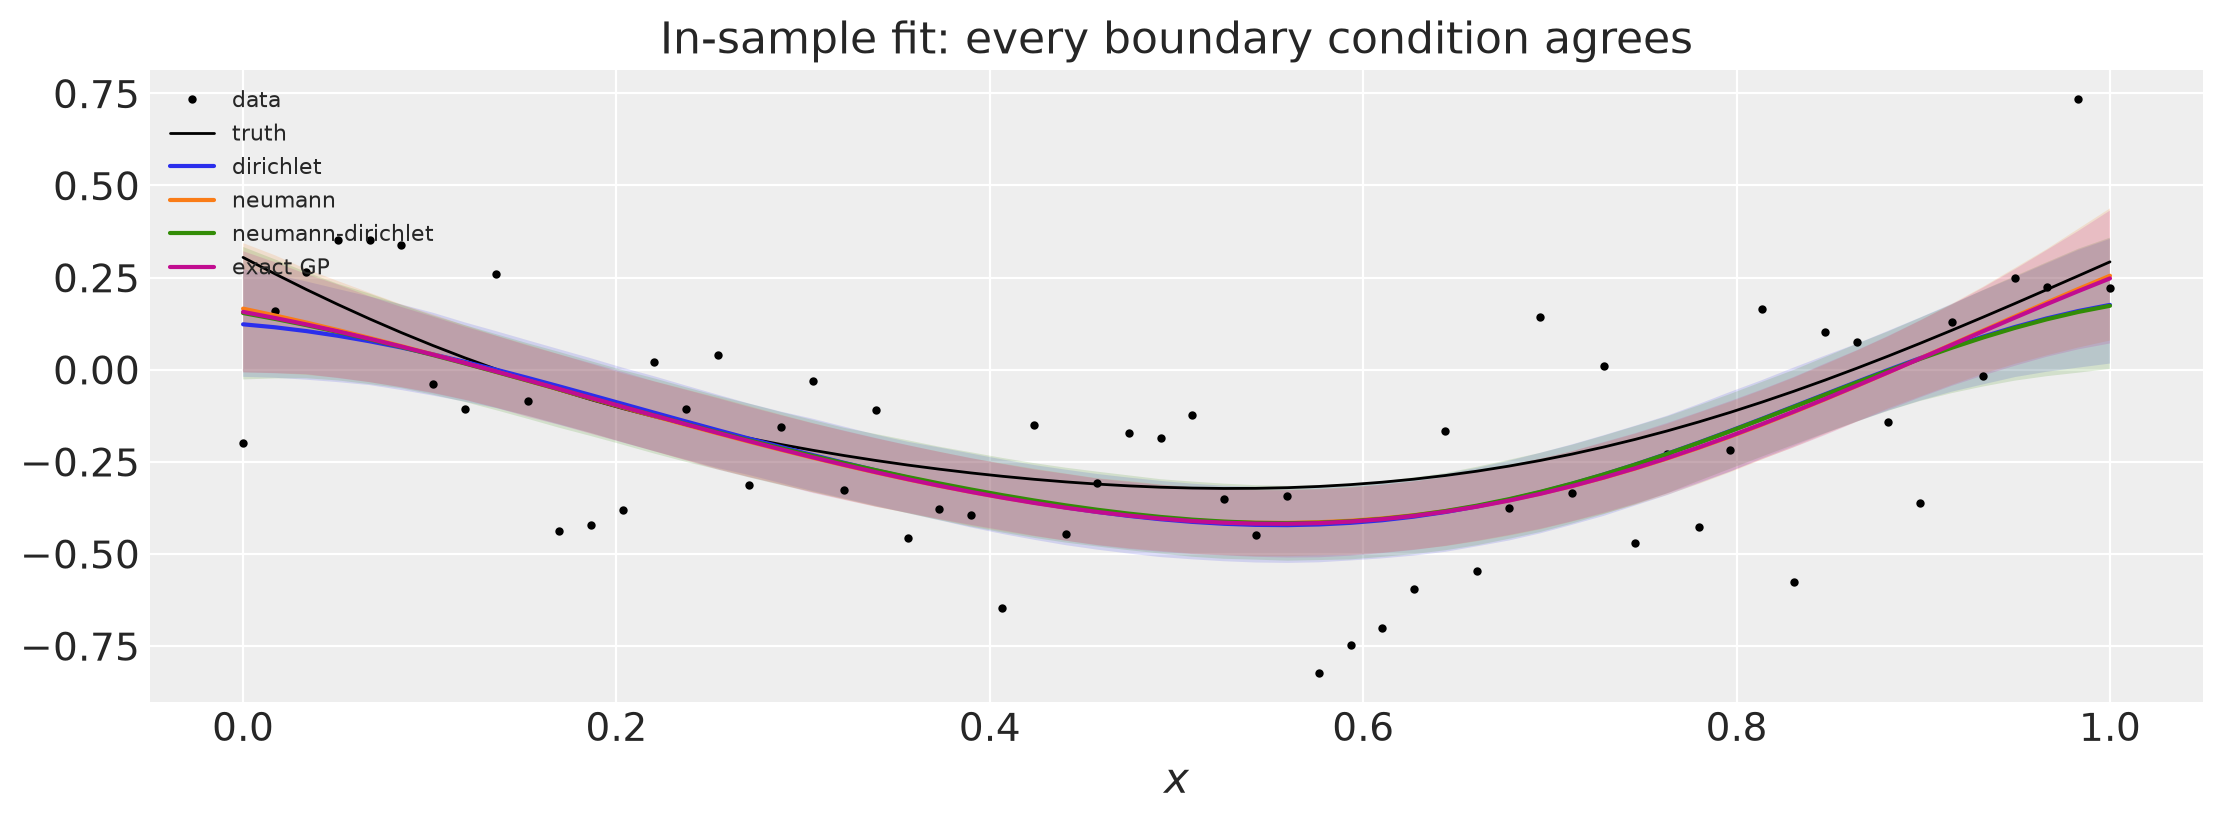

In [6]:
ell_true, noise_true = 0.4, 0.3
x = np.linspace(0.0, 1.0, 60)
f = draw_gp(x, ell_true)
y = f + noise_true * rng.standard_normal(len(x))
X = x[:, None]

results_in = {b: fit_hsgp(b, X, y, X) for b in BOUNDARIES}
results_in["exact GP"] = fit_exact(X, y, X)
plot_results(results_in, x, y, x, f, x, "In-sample fit: every boundary condition agrees")

In [7]:
box = {"L": 0.75, "m": 15}
models_in = {
    b: (lambda a, bb, eta, ell, b=b: hsgp_kernel(b, a - 0.5, bb - 0.5, eta=eta, ell=ell, **box))
    for b in BOUNDARIES
}
models_in["exact GP"] = k_expquad
replicated_table(models_in, lambda: draw_gp(np.r_[x, x], ell_true), x, x, noise_true)

               model    RMSE  90% cov   sd(last)   (100 replications)
           dirichlet   0.089     0.80      0.100
             neumann   0.085     0.82      0.121
   neumann-dirichlet   0.086     0.84      0.097
            exact GP   0.085     0.83      0.123


All four posteriors coincide, in the figure and in the replicated table. If your predictions
live inside the data and $c \geq 1.2$, the boundary condition is irrelevant and you should keep
the default. An example that only looks at in-sample fit cannot show a difference; this is by
construction, not by accident.

## Where a boundary condition shines: constraints no $c$ can express

Consider a smooth profile $f(r)$ on $r \in [0, R]$ that is symmetric about the origin, so
$f'(0) = 0$, and decays to the background level at the outer edge, $f(R) = 0$ (a brightness
profile, a concentration around a source, a pressure profile). We observe it only on the
inner part $r \in [0.1, 0.7]$ and want to reconstruct it on all of $[0, 1]$.

No value of $c$ makes the Dirichlet basis express $f'(0) = 0$: the sine basis has no flat mode.
With `"neumann-dirichlet"` and the box placed exactly on the physical domain ($L = 0.5$
around $r = 0.5$, i.e. $c = 1$, the smallest possible box) both constraints are built in. To
put the box on the physical domain rather than around the midpoint of the observations, we
build the basis on a grid covering the whole domain with `prior_linearized` and index the
observed rows in the likelihood.

Two truths are used: one where the constraints hold exactly (a GP draw conditioned on them),
and one where they hold only approximately ($f(R)$ is only *near* zero), because a reviewer
will rightly ask whether the first is circular.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ell, eta, sigma, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ell, eta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [f_new]


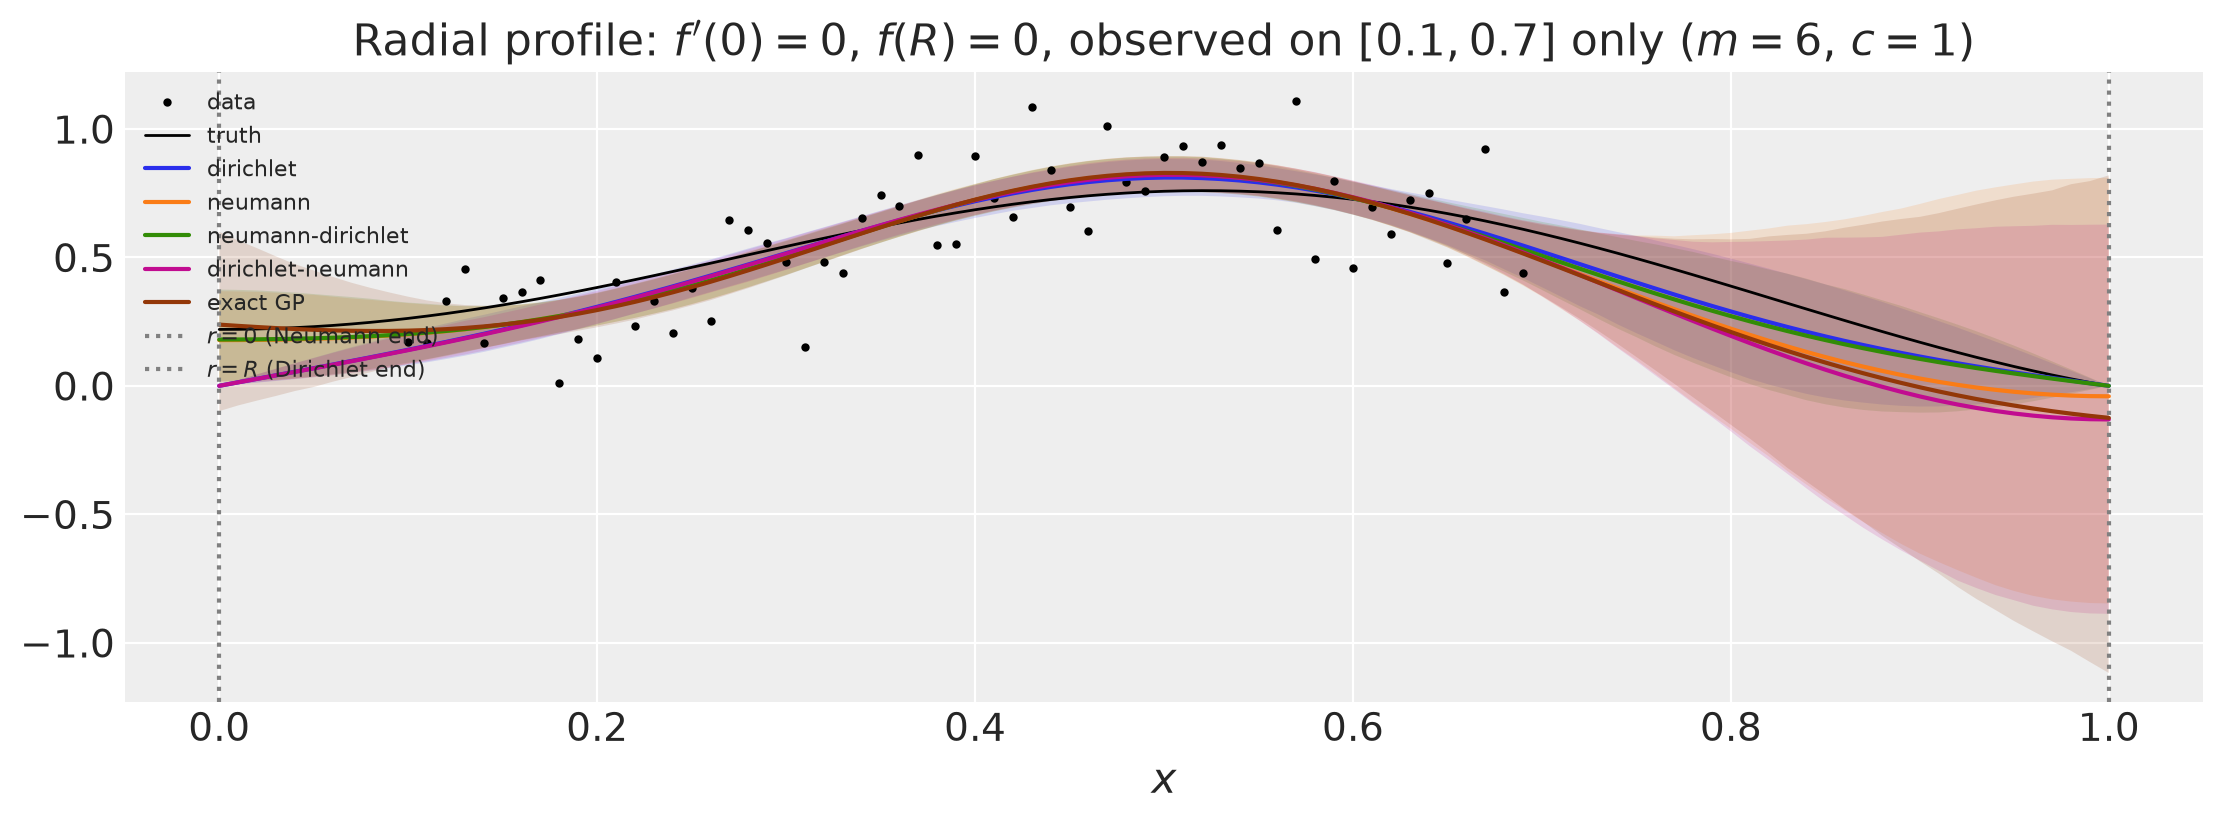

In [8]:
def draw_constrained_profile(r, ell, eta=1.0, edge_sd=0.0):
    """GP draw on r with f'(0) = 0 exactly and f(1) ~ N(0, edge_sd^2) (edge_sd=0: exactly zero)."""

    def k(a, b):
        return eta**2 * np.exp(-0.5 * ((a - b) / ell) ** 2)

    def dk(a, b):  # cov(f(a), f'(b)) = d/db k(a, b)
        return k(a, b) * (a - b) / ell**2

    def ddk(a, b):  # cov(f'(a), f'(b))
        return k(a, b) * (1 / ell**2 - (a - b) ** 2 / ell**4)

    Kff = k(r[:, None], r[None, :])
    C = np.c_[dk(r, 0.0), k(r, 1.0)]  # cov(f(r), [f'(0), f(1)])
    Kcc = np.array([[ddk(0.0, 0.0), dk(1.0, 0.0)], [dk(1.0, 0.0), k(1.0, 1.0)]])
    target = np.array([0.0, edge_sd * rng.standard_normal()])  # f'(0) = 0, f(1) = small value
    mean = C @ np.linalg.solve(Kcc, target)
    Kc = Kff - C @ np.linalg.solve(Kcc, C.T)
    return mean + np.linalg.cholesky(Kc + 1e-9 * np.eye(len(r))) @ rng.standard_normal(len(r))


r_grid = np.linspace(0.0, 1.0, 101)
obs = (r_grid >= 0.1) & (r_grid <= 0.7)
f_r = draw_constrained_profile(r_grid, ell=0.5)
y_r = f_r[obs] + 0.2 * rng.standard_normal(obs.sum())


def fit_hsgp_on_grid(boundary, r_grid, obs, y, m=6):
    with pm.Model():
        cov_func, sigma = hyperpriors()
        gp = pm.gp.HSGP(m=[m], L=[0.5], boundary=boundary, cov_func=cov_func)
        phi, sqrt_psd = gp.prior_linearized(r_grid[:, None])
        beta = pm.Normal("beta", size=gp.n_basis_vectors)
        f_new = pm.Deterministic("f_new", phi @ (beta * sqrt_psd))
        pm.Normal("y", mu=f_new[obs], sigma=sigma, observed=y)
        idata = pm.sample(**NUTS)
    return stack(idata.posterior, "f_new")


RADIAL = ["dirichlet", "neumann", "neumann-dirichlet", "dirichlet-neumann"]
results_r = {b: fit_hsgp_on_grid(b, r_grid, obs, y_r) for b in RADIAL}
results_r["exact GP"] = fit_exact(r_grid[obs][:, None], y_r, r_grid[:, None])
plot_results(
    results_r,
    r_grid[obs],
    y_r,
    r_grid,
    f_r,
    r_grid,
    "Radial profile: $f'(0) = 0$, $f(R) = 0$, observed on $[0.1, 0.7]$ only ($m = 6$, $c = 1$)",
    vlines=[(0.0, "$r = 0$ (Neumann end)"), (1.0, "$r = R$ (Dirichlet end)")],
)

In [9]:
r_obs, r_pred = r_grid[obs], r_grid[~obs]  # metrics on the unobserved part of the domain
models_r = {
    b: (
        lambda a, bb, eta, ell, b=b: hsgp_kernel(b, a - 0.5, bb - 0.5, L=0.5, m=6, eta=eta, ell=ell)
    )
    for b in RADIAL
}
models_r["exact GP"] = k_expquad


def truth_radial(edge_sd):
    def draw():
        f_all = draw_constrained_profile(r_grid, ell=0.5, edge_sd=edge_sd)
        return np.r_[f_all[obs], f_all[~obs]]

    return draw


print("constraints hold exactly:")
replicated_table(models_r, truth_radial(0.0), r_obs, r_pred, noise_true=0.2)
print("\nf(R) only approximately zero (sd 0.3):")
replicated_table(models_r, truth_radial(0.3), r_obs, r_pred, noise_true=0.2)

constraints hold exactly:


               model    RMSE  90% cov   sd(last)   (100 replications)
           dirichlet   0.250     0.64      0.000
             neumann   0.203     0.58      0.137
   neumann-dirichlet   0.053     0.58      0.000
   dirichlet-neumann   0.303     0.67      0.631
            exact GP   0.174     0.72      0.225

f(R) only approximately zero (sd 0.3):


               model    RMSE  90% cov   sd(last)   (100 replications)
           dirichlet   0.339     0.53      0.000
             neumann   0.196     0.62      0.145
   neumann-dirichlet   0.142     0.41      0.000
   dirichlet-neumann   0.360     0.66      0.700
            exact GP   0.185     0.75      0.231


When the constraints hold, `"neumann-dirichlet"` reconstructs the unobserved ends far better
than the exact GP, which knows nothing about the symmetry or the decay, and it does so with the
smallest possible box ($c = 1$). When the outer constraint only holds approximately, much of
that advantage is gone: the RMSE is comparable to the exact GP's, and the model is overconfident
at that end because it pins $f(R)$ exactly where the truth only comes close (coverage drops).
A boundary condition pays off in proportion to how well it actually holds. The default
Dirichlet is wrong at $r = 0$ (it pins the profile to zero there) and the reversed
`"dirichlet-neumann"` is wrong at both ends and is the worst of all. **A mismatched boundary
condition is worse than the default**: use a non-default condition only when you know what the
function does at that edge. Plain `"neumann"` is the most forgiving choice when you are unsure.

## Where Neumann helps, with caveats: forecasting just past the data

A new GP draw on $[0, 1.2]$; we observe $[0, 1]$ and forecast $(1, 1.2]$, half a lengthscale
past the last observation, with the same $c = 1.5$ as before (box edge at $1.25$). A Dirichlet
end forces the forecast to zero *with vanishing uncertainty*; a Neumann end lets it flatten out
and keep its uncertainty. The exact GP is the reference.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ell, eta, sigma, f_hsgp_coeffs]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


Sampling: []


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ell, eta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [f_new]


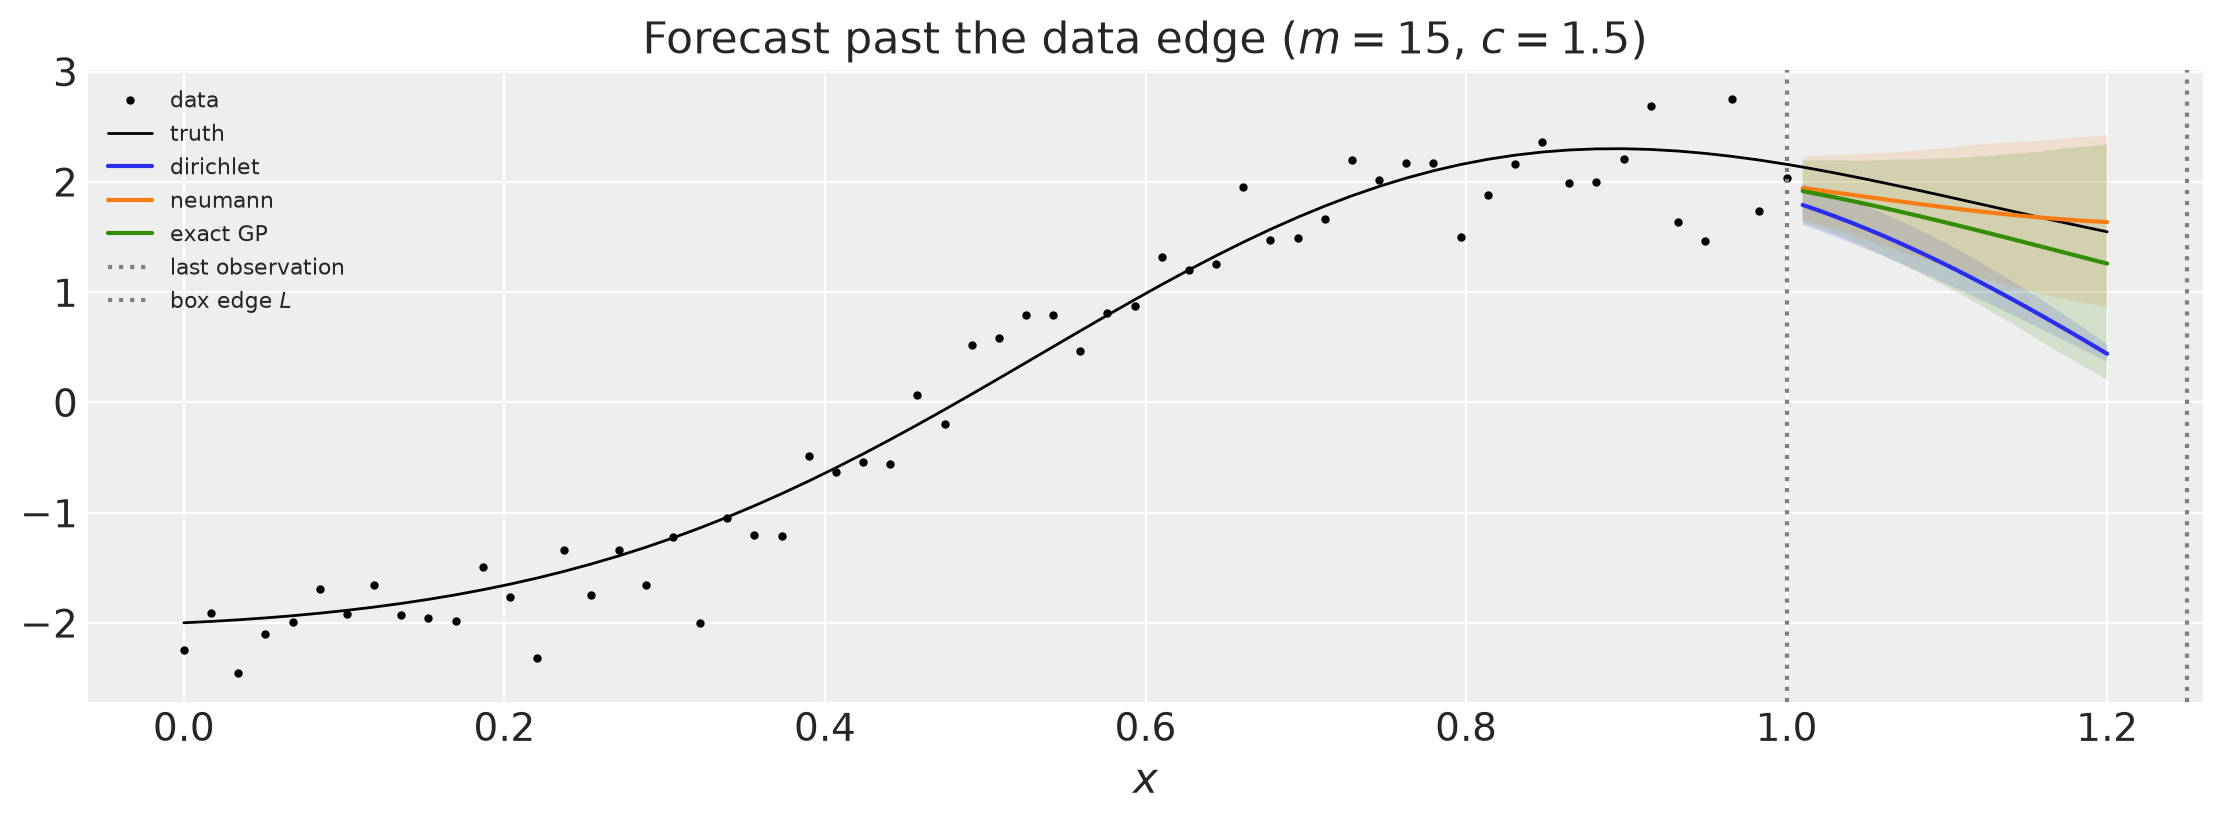

In [10]:
x_new = np.linspace(1.0, 1.2, 21)[1:]
x_all = np.r_[x, x_new]
f_all = draw_gp(x_all, ell_true)
f, f_new = f_all[: len(x)], f_all[len(x) :]
y = f + noise_true * rng.standard_normal(len(x))
X_new = x_new[:, None]

results_fc = {b: fit_hsgp(b, X, y, X_new) for b in ["dirichlet", "neumann"]}
results_fc["exact GP"] = fit_exact(X, y, X_new)
plot_results(
    results_fc,
    x,
    y,
    x_all,
    f_all,
    x_new,
    "Forecast past the data edge ($m = 15$, $c = 1.5$)",
    vlines=[(1.0, "last observation"), (1.25, "box edge $L$")],
)

In [11]:
for c in [1.5, 2.0]:
    L = c * 0.5
    models_fc = {
        f"{b} (c={c})": (
            lambda a, bb, eta, ell, b=b, L=L: hsgp_kernel(
                b, a - 0.5, bb - 0.5, L=L, m=15, eta=eta, ell=ell
            )
        )
        for b in ["dirichlet", "neumann"]
    }
    models_fc["exact GP"] = k_expquad
    replicated_table(models_fc, lambda: draw_gp(x_all, ell_true), x, x_new, noise_true)
    print()

               model    RMSE  90% cov   sd(last)   (100 replications)
   dirichlet (c=1.5)   0.367     0.35      0.048
     neumann (c=1.5)   0.257     0.70      0.258
            exact GP   0.242     0.83      0.330



               model    RMSE  90% cov   sd(last)   (100 replications)
   dirichlet (c=2.0)   0.236     0.74      0.245
     neumann (c=2.0)   0.253     0.79      0.361
            exact GP   0.241     0.81      0.339



At $c = 1.5$ the Dirichlet forecast band collapses and covers the truth far less than 90% of
the time; the Neumann forecast and its uncertainty are close to the exact GP. This is the
situation of many time-series uses of HSGP (trend components, time-varying coefficients):
predictions are made right where the Dirichlet artefact lives.

Three caveats, all visible in the table:

1. The gain is in **calibration**, not point accuracy. Once $c = 2$ the Dirichlet model is as
   accurate as the exact GP and Neumann is no better.
2. The exact GP reverts to its mean at the scale of the lengthscale; Neumann flattens instead.
   Over horizons shorter than a lengthscale these agree; over longer horizons Neumann is
   *over*-dispersed and neither approximation is trustworthy.
3. PyMC's `approx_hsgp_hyperparams` already tells you to include the prediction range in
   `x_range`, which for this problem recommends $c \approx 4$. That is the library's answer to
   "my forecast reverts to zero"; it costs proportionally more basis functions ($m \propto c$
   per input dimension). A Neumann end at small $c$ is the cheaper way to get calibrated
   short-horizon forecasts, not a replacement for choosing $c$ well.

## How to choose

| Your situation | Recommendation |
|---|---|
| Predictions stay inside the data, $c \geq 1.2$ | Default `"dirichlet"`; the condition is irrelevant |
| Function known to have zero slope at an edge (symmetry axis, zero flux, plateau) | Neumann at that end, box edge placed on it ($c = 1$ via `L`, basis built on the full domain) |
| Function known to vanish at an edge | Dirichlet at that end, box edge placed on it |
| One of each | `"neumann-dirichlet"` or `"dirichlet-neumann"` |
| Forecasting a short horizon just past the data with a small $c$ | `"neumann"` for calibrated uncertainty; or increase $c$ (more basis functions) |
| You want the unconstrained GP near the edge | Increase $c$; no boundary condition gives this |

Two reminders. First, the guidance for $m$ and $c$ does not change with the boundary
condition. Second, a boundary condition that does not match the function is worse than the
default; when unsure, `"neumann"` degrades most gracefully.

## References

:::{bibliography}
:filter: docname in docnames
:::

## Authors

- Authored by [Juan Orduz](https://juanitorduz.github.io/) in September 2026.

## Watermark

In [12]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor

Last updated: Sun, 13 Sep 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.17.1

pytensor: 3.3.1

arviz     : 1.3.0
matplotlib: 3.11.2
numpy     : 2.5.3
pymc      : 6.3.2+3.g3f3b1082e

Watermark: 2.6.0



:::{include} ../page_footer.md
:::